# Hedging analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from bin_model import BinomialModel
from options import EuropeanCall, EuropeanPut, AmericanPut, AmericanCall


def run_hedging_analysis(t_selected, option_obj, model):
    N = model.N
    K = option_obj.K
    
    # obliczanie wartości drzewa i wartości hedingowych 
    opt_tree = option_obj.calc_opt_tree(model)
    delta_tree, alpha_tree = option_obj.price_with_hedging(model)
    stock_tree = model.generate_stock_tree()
    
    # listy do wykresów
    rows = []
    prices, deltas, alphas = [], [], []

    # wyciągnięcie wartości 
    s_step = stock_tree.get_step(t_selected)
    v_step = opt_tree.get_step(t_selected)
    
    # liczenie delty i alfy tylko dla czasu przedostatniego węzła, bo w czasie N nie ma już hedgingu
    has_hedge = t_selected < N
    if has_hedge:
        d_step = delta_tree.get_step(t_selected)
        a_step = alpha_tree.get_step(t_selected)

    for i in range(t_selected + 1):
        s_val = s_step[i]
        v_val = v_step[i]
        
        if has_hedge:
            d_val = d_step[i]
            a_val = a_step[i]
            portfolio_val = d_val * s_val + a_val
            deltas.append(d_val)
            alphas.append(a_val)
        else:
            d_val, a_val, portfolio_val = None, None, v_val
            
        prices.append(s_val)
        rows.append({
            "Węzeł (i,t)": f"({i}, {t_selected})",
            "Cena Akcji S_t": s_val,
            "Wartość Opcji V_t": v_val,
            "Delta": d_val,
            "Alpha": a_val,
            "Portfel Replikujący": portfolio_val
        })
    
    # tworzenie wykresu
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    if has_hedge:
        # Sortowanie dla ładnej linii na wykresie
        sorted_data = sorted(zip(prices, deltas, alphas))
        p_plot, d_plot, a_plot = zip(*sorted_data)
        
        ax1.set_xlabel('Cena Akcji (S_t)')
        ax1.set_ylabel(r'Delta ($\Delta$)', color='tab:green')
        ax1.plot(p_plot, d_plot, color='tab:green', marker='o', label='Delta')
        ax1.tick_params(axis='y', labelcolor='tab:green')
        
        ax2 = ax1.twinx()
        ax2.set_ylabel(r'Alpha ($\alpha$)', color='tab:blue')
        ax2.plot(p_plot, a_plot, color='tab:blue', marker='s', linestyle='--', label='Alpha')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc='center right')
    else:
        ax1.text(0.5, 0.5, "Wygaśnięcie (t=N)\nBrak Delty i Alphy", ha='center', va='center', fontsize=12)

    ax1.axvline(K, color='red', linestyle=':', label=f'Strike K={K}')
    ax1.set_title(f"{option_obj.__class__.__name__} - Portfel Replikujący (Krok {t_selected})")
    ax1.grid(True, alpha=0.2)
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)

    # 4. Tabela
    df = pd.DataFrame(rows)
    return df



# funkcje do wykresu 
def analyze_european_call(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, EuropeanCall(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))

def analyze_european_put(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, EuropeanPut(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))

def analyze_american_call(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, AmericanCall(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))

def analyze_american_put(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, AmericanPut(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))



def main_dashboard(option_choice, t):
    if option_choice == 'Euro Call': analyze_european_call(t)
    elif option_choice == 'Euro Put': analyze_european_put(t)
    elif option_choice == 'Amer Call': analyze_american_call(t)
    elif option_choice == 'Amer Put': analyze_american_put(t)


S0, K, T, r, sigma = 50, 48, 2, 0.02, 0.3
N = 24
dt = T/N
u = np.exp(sigma * np.sqrt(dt))
d = 1/u

widgets.interact(
    main_dashboard,
    option_choice=['Euro Call', 'Euro Put', 'Amer Call', 'Amer Put'],
    t=widgets.IntSlider(value=0, min=0, max=N, step=1, description='Krok t:')
);

interactive(children=(Dropdown(description='option_choice', options=('Euro Call', 'Euro Put', 'Amer Call', 'Am…

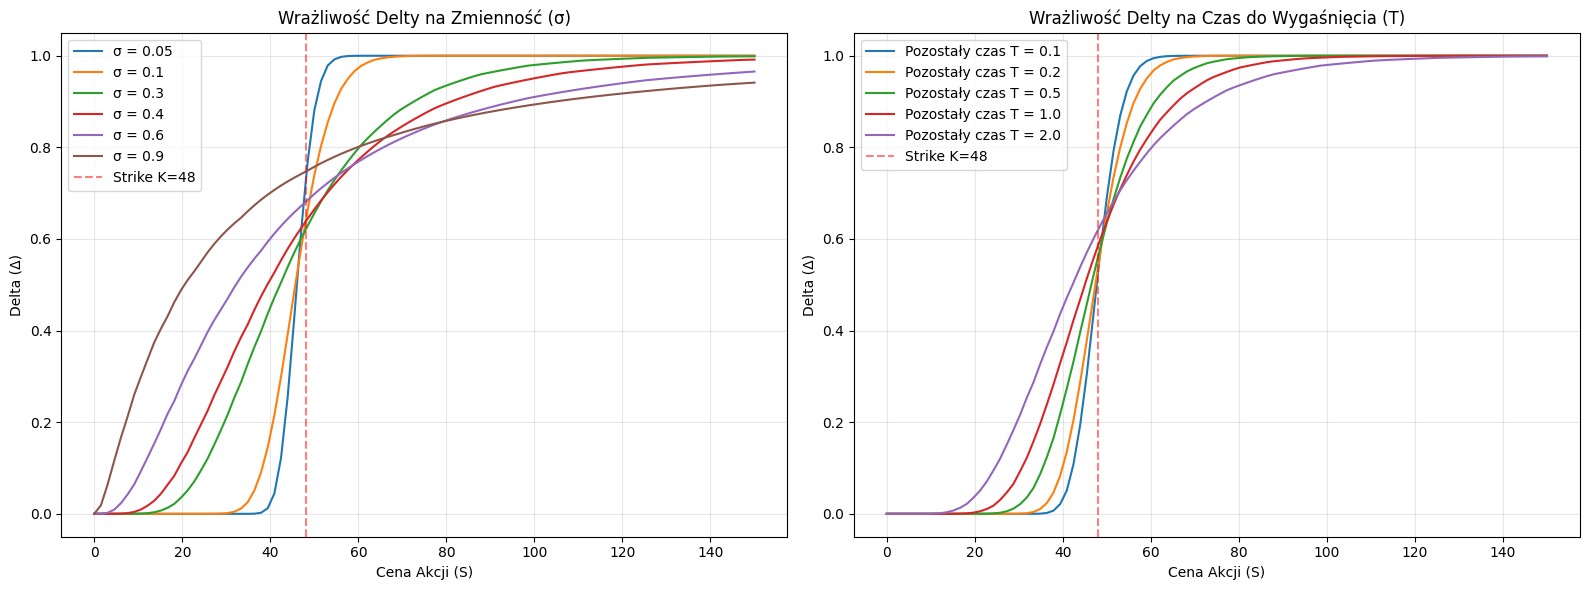

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta_sensitivities():
    S_range = np.linspace(0.01, 150, 100)
    
    K_val = 48
    r_val = 0.02
    T_total = 2.0
    N_steps = 50 
    dt_val = T_total / N_steps

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


    sigmas = [0.05,0.1, 0.3, 0.4, 0.6, 0.9]
    for s in sigmas:
        deltas = []
        u_s = np.exp(s * np.sqrt(dt_val))
        d_s = 1/u_s
        for s_val in S_range:
            # Tworzymy model dla konkretnego punktu S0
            temp_model = BinomialModel(s_val, N_steps, dt_val, u_s, d_s, r_val)
            opt = EuropeanCall(K_val)
            d_tree, _ = opt.price_with_hedging(temp_model)
            deltas.append(d_tree[0, 0]) # Pobieramy Deltę w chwili t=0
        
        ax1.plot(S_range, deltas, label=f'σ = {s}')

    ax1.set_title("Wrażliwość Delty na Zmienność (σ)")
    ax1.set_xlabel("Cena Akcji (S)")
    ax1.set_ylabel("Delta (Δ)")
    ax1.axvline(K_val, color='red', linestyle='--', alpha=0.5, label=f'Strike K={K_val}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    times_to_mat = [0.1,0.2, 0.5,1.0, 2.0] 
    sigma_fixed = 0.3
    
    for t_rem in times_to_mat:
        deltas = []
        dt_rem = t_rem / N_steps
        u_t = np.exp(sigma_fixed * np.sqrt(dt_rem))
        d_t = 1/u_t
        for s_val in S_range:
            temp_model = BinomialModel(s_val, N_steps, dt_rem, u_t, d_t, r_val)
            opt = EuropeanCall(K_val)
            d_tree, _ = opt.price_with_hedging(temp_model)
            deltas.append(d_tree[0, 0])
            
        ax2.plot(S_range, deltas, label=f'Pozostały czas T = {t_rem}')

    ax2.set_title("Wrażliwość Delty na Czas do Wygaśnięcia (T)")
    ax2.set_xlabel("Cena Akcji (S)")
    ax2.set_ylabel("Delta (Δ)")
    ax2.axvline(K_val, color='red', linestyle='--', alpha=0.5, label=f'Strike K={K_val}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_delta_sensitivities()